# Time-Weighted Returns (Cont.)
<p style="color:darkblue; "><b>A TurningBull Notebook</b>

This notebook is a continuation of **Time-Weighted Returns**.  The objective is to produce a cumulative return plot of three major U.S. stock indices, the S&P 500, Nasdaq 100 and Russell 2K.

In [1]:
import yfinance as yf 
import pandas as pd 
import matplotlib.pyplot as plt 

Matplotlib is building the font cache; this may take a moment.


In [2]:
## Set our parameters
symbols = ['^GSPC', '^NDX', '^RUT']     # S&P 500, Nasdaq, Russell 2000.
start_date = '2020-01-01'               
end_date = '2024-12-31'                 # 5 years of data.
frequency = '1mo'                       # Monthly data.

In [5]:
prices = yf.download(symbols, start=start_date, end=end_date, interval=frequency)['Close']

print (prices.head())

[*********************100%***********************]  3 of 3 completed

Ticker            ^GSPC         ^NDX         ^RUT
Date                                             
2020-01-01  3225.520020  8991.509766  1614.060059
2020-02-01  2954.219971  8461.830078  1476.430054
2020-03-01  2584.590088  7813.500000  1153.099976
2020-04-01  2912.429932  9000.509766  1310.660034
2020-05-01  3044.310059  9555.530273  1394.040039


In [33]:
returns = \
(
    prices
    .assign(SPY = lambda df_: df_['^GSPC'].pct_change().add(1).cumprod().sub(1).mul(100).round(2),
            QQQ = lambda df_: df_['^NDX'].pct_change().add(1).cumprod().sub(1).mul(100).round(2),
            IWM = lambda df_: df_['^RUT'].pct_change().add(1).cumprod().sub(1).mul(100).round(2))
    .dropna()
    .loc[:,['SPY', 'QQQ', 'IWM']]
)

print (returns.head())

Ticker        SPY    QQQ    IWM
Date                           
2020-02-01  -8.41  -5.89  -8.53
2020-03-01 -19.87 -13.10 -28.56
2020-04-01  -9.71   0.10 -18.80
2020-05-01  -5.62   6.27 -13.63
2020-06-01  -3.88  12.96 -10.70


In [34]:
annualized_returns = \
(
    returns
    .div(100)
    .add(1) 
    .pow(12. / returns.index.size)
    .sub(1)
    .mul(100)
    .round(2)
    .iloc[-1]
)

print (annualized_returns)

Ticker
SPY    13.00
QQQ    18.84
IWM     6.80
Name: 2024-12-01 00:00:00, dtype: float64


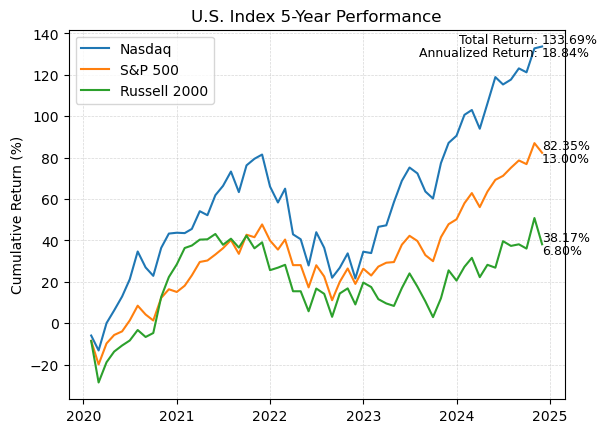

In [54]:
fig, ax = plt.subplots()

date_format = '%b-%y' 
ax.plot(returns.index, returns['QQQ'], label='Nasdaq')
ax.plot(returns.index, returns['SPY'], label='S&P 500')
ax.plot(returns.index, returns['IWM'], label='Russell 2000')

ax.set_title('U.S. Index 5-Year Performance')
ax.set_ylabel('Cumulative Return (%)')
ax.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.5)
ax.legend()

ax.text(returns.index[-1], returns['QQQ'].iloc[-1], f'{returns["QQQ"].iloc[-1]:.2f}%',
         verticalalignment='bottom', horizontalalignment='left', fontsize=9, color='black')
ax.text(returns.index[-1], returns['QQQ'].iloc[-1], f'{annualized_returns['QQQ']:.2f}%',
        verticalalignment='top', horizontalalignment='left', fontsize=9, color='black')

ax.text(returns.index[-1], returns['QQQ'].iloc[-1], 'Total Return: ',
         verticalalignment='bottom', horizontalalignment='right', fontsize=9, color='black')
ax.text(returns.index[-1], returns['QQQ'].iloc[-1], 'Annualized Return: ',
         verticalalignment='top', horizontalalignment='right', fontsize=9, color='black')

ax.text(returns.index[-1], returns['SPY'].iloc[-1], f'{returns["SPY"].iloc[-1]:.2f}%',
        verticalalignment='bottom', horizontalalignment='left', fontsize=9, color='black')
ax.text(returns.index[-1], returns['SPY'].iloc[-1], f'{annualized_returns["SPY"]:.2f}%',
        verticalalignment='top', horizontalalignment='left', fontsize=9, color='black')

ax.text(returns.index[-1], returns['IWM'].iloc[-1], f'{returns["IWM"].iloc[-1]:.2f}%',
        verticalalignment='bottom', horizontalalignment='left', fontsize=9, color='black')
ax.text(returns.index[-1], returns['IWM'].iloc[-1], f'{annualized_returns["IWM"]:.2f}%',
        verticalalignment='top', horizontalalignment='left', fontsize=9, color='black')

plt.show()